In [1]:
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.lines import Line2D 
from matplotlib import gridspec

import scanpy as sc

import os

import scvi

import seaborn as sns


def order_m(m):
    n = min(*m.shape)
    
    ordered_cols = []
    remain_cols = list(range(m.shape[1]))
    
    for i in range(n):
        ic = m[i, remain_cols].argmax()
        c = remain_cols[ic]
        ordered_cols.append(c)
        remain_cols.remove(c)
    
    return ordered_cols, remain_cols

# Some canonical markers for PBMC cell types that I found
canonical_markers = ["IL32", "LTB", "CD3D",
    "IL7R", "LDHB", "FCGR3A", 
    "CD68", "MS4A1", "GNLY", 
    "CD3E", "CD14", "CD14", 
    "FCGR3A", "LYZ", "PPBP", 
    "CD8A", "PPBP", "CST3", 
    "NKG7", "MS4A7", "MS4A1", 
    "CD8A", "CD4", "NCAM1"]

    

/home/syyang/python_virtuenv/mrvi_3.11/lib/python3.11/site-packages/anndata/utils.py:429: FutureWarning: Importing read_csv from `anndata` is deprecated. Import anndata.io.read_csv instead.
  warnings.warn(msg, FutureWarning)
/home/syyang/python_virtuenv/mrvi_3.11/lib/python3.11/site-packages/anndata/utils.py:429: FutureWarning: Importing read_loom from `anndata` is deprecated. Import anndata.io.read_loom instead.
  warnings.warn(msg, FutureWarning)
/home/syyang/python_virtuenv/mrvi_3.11/lib/python3.11/site-packages/anndata/utils.py:429: FutureWarning: Importing read_text from `anndata` is deprecated. Import anndata.io.read_text instead.
  warnings.warn(msg, FutureWarning)
/home/syyang/python_virtuenv/mrvi_3.11/lib/python3.11/site-packages/anndata/utils.py:429: FutureWarning: Importing CSCDataset from `anndata.experimental` is deprecated. Import anndata.abc.CSCDataset instead.
  warnings.warn(msg, FutureWarning)
/home/syyang/python_virtuenv/mrvi_3.11/lib/python3.11/site-packages/anndat

In [2]:
## Downloaded CR-arc count matrix results
data_dir = '/mnt/hdd_bob/syy/adipose/atac/protocol_benchmark/downloaded_counts/VIB_10xmultiome_2'



## Entropy filtered atac
entropy_dir = '/mnt/hdd_bob/syy/adipose/atac/res/VIB_10xmultiome_2_WS3000F'



# Load peak annotations [including peak AUC score from Genrich peaks]
annotation_dir = os.path.join(entropy_dir, 'annotation')
peaks_annot = pd.read_csv(os.path.join(annotation_dir, 'annotated_peaks.bed'),      sep='\t')
entropy_peaks_annot = pd.read_csv(os.path.join(annotation_dir, 'annotated_entropy_peaks.bed'), sep='\t')
lost_peaks_annot = pd.read_csv(os.path.join(annotation_dir, 'annotated_lost_peaks.bed'), sep='\t')
newly_discovered_peaks_annot = pd.read_csv(os.path.join(annotation_dir, 'annotated_newly_discovered_peaks.bed'),  sep='\t')


In [3]:

## calcualte peak size
newly_discovered_peaks_annot['peak_size'] = newly_discovered_peaks_annot['End'] - newly_discovered_peaks_annot['Start']
lost_peaks_annot['peak_size'] = lost_peaks_annot['End'] - lost_peaks_annot['Start']

peaks_annot['peak_size'] = peaks_annot['End'] - peaks_annot['Start']
entropy_peaks_annot['peak_size'] = entropy_peaks_annot['End'] - entropy_peaks_annot['Start']

## Peak AUC score 

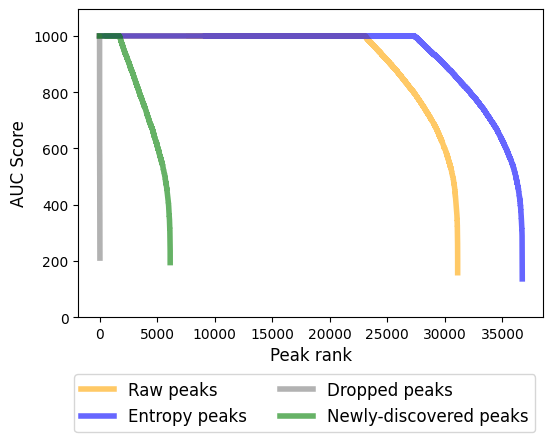

In [89]:
fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(peaks_annot['Peak Score'].sort_values(ascending=False), '-', color='orange', alpha=0.6, label='Raw peaks', lw=4)
ax.plot(entropy_peaks_annot['Peak Score'].sort_values(ascending=False), '-', color='blue', alpha=0.6, label='Entropy peaks', lw=4)
ax.plot(lost_peaks_annot['Peak Score'].sort_values(ascending=False), '-', color='gray', alpha=0.6, label='Dropped peaks', lw=4)
ax.plot(newly_discovered_peaks_annot['Peak Score'].sort_values(ascending=False), '-', color='green', alpha=0.6, label='Newly-discovered peaks', lw=4)
# ax.set_title('Peak Score Comparison', fontsize=12)
ax.set_xlabel('Peak rank', fontsize=12)
ax.set_ylabel('AUC Score', fontsize=12)
ax.set_ylim(0, ax.get_ylim()[1]*1.05)
ax.legend( loc='lower right', bbox_to_anchor=(1, -0.4), fontsize=12, ncol=2)

--- 	 Raw peaks , Entropy Peaks , Newly-discovered Peaks , Dropped Peaks
Mean [943.8465419719759, 943.6453483623295, 806.1140250855188, 544.0571428571428]
Median [1000.0, 1000.0, 845.0, 509.0]


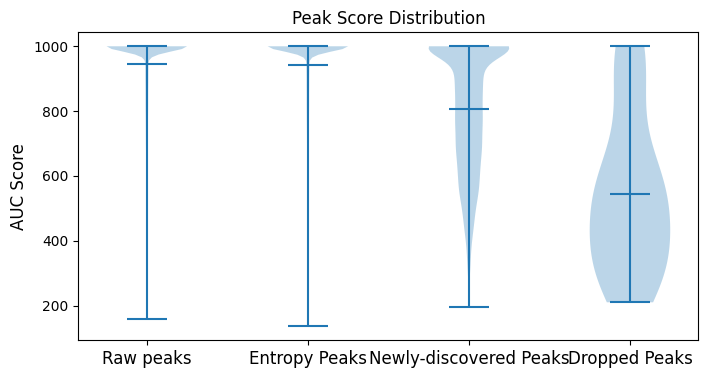

In [90]:
fig, ax = plt.subplots(figsize=(8, 4))
x_positions = range(4)
width = 0.5 

auc_score = [
             peaks_annot['Peak Score'], entropy_peaks_annot['Peak Score'], 
             newly_discovered_peaks_annot['Peak Score'], lost_peaks_annot['Peak Score'], 
             ]
mean_score = [np.mean(a) for a in auc_score]
median_score = [np.median(a) for a in auc_score]

ax.violinplot(auc_score, widths=width, positions=x_positions, showmeans=True,  vert=True)

ax.set_xticks(x_positions, [ 'Raw peaks', 'Entropy Peaks', 'Newly-discovered Peaks', 'Dropped Peaks'], fontsize=12)  
ax.set_ylabel('AUC Score', fontsize=12)
ax.set_title('Peak Score Distribution', fontsize=12)

print ('--- \t Raw peaks , Entropy Peaks , Newly-discovered Peaks , Dropped Peaks')
print (f'Mean {mean_score}')
print (f'Median {median_score}')

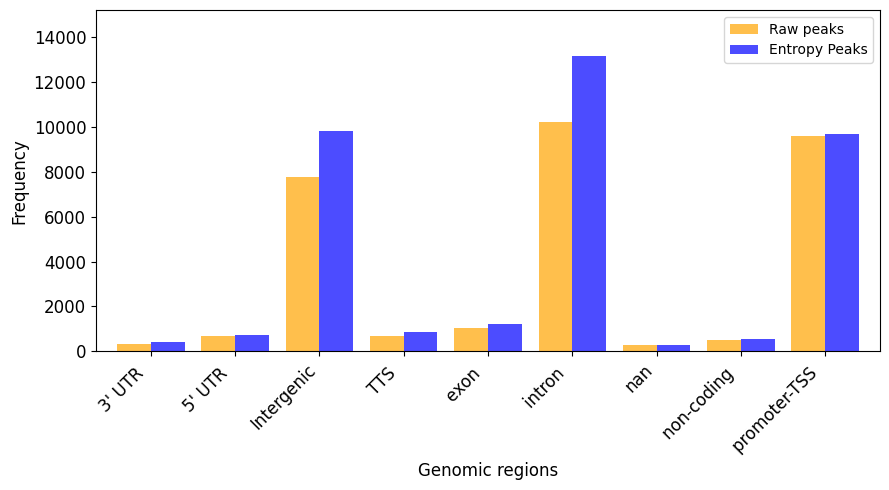

In [91]:
def simplify_annotation(annot_df, inplace=False):
    """
    Simplify the Annotation column.
    """
    if not inplace:
        annot_df = annot_df.copy()
        annot_df['simple_annotation'] = annot_df['Annotation'].apply(lambda x: str(x).split('(')[0])  
        return annot_df
    else:
        # in place change of the  DataFrame
        annot_df['simple_annotation'] = annot_df['Annotation'].apply(lambda x: str(x).split('(')[0])  
        
simplify_annotation(peaks_annot, inplace=True)
simplify_annotation(entropy_peaks_annot, inplace=True)
simplify_annotation(lost_peaks_annot, inplace=True)
simplify_annotation(newly_discovered_peaks_annot, inplace=True)

        
standard_peak_freq = peaks_annot['simple_annotation'].value_counts()
entropy_peak_freq = entropy_peaks_annot['simple_annotation'].value_counts()
newly_discovered_peak_freq = newly_discovered_peaks_annot['simple_annotation'].value_counts()
lost_standard_peak_freq = lost_peaks_annot['simple_annotation'].value_counts()

freq_df = pd.DataFrame({
    'Raw peaks': standard_peak_freq,
    'Entropy Peaks': entropy_peak_freq
}).fillna(0)

fig, ax = plt.subplots(figsize=(9, 5))
freq_df.plot(kind='bar', width=0.8, alpha=0.7, ax=ax, color=['orange', 'blue'], fontsize=12)

# for i, tick in enumerate(ax.get_xticklabels()):
#     region_type = tick.get_text()
#     count = entropy_peak_freq[region_type]
#     ax.text(i + .22, count +400 , f'{count}', ha='center', fontsize=12)

# for i, tick in enumerate(ax.get_xticklabels()):
#     region_type = tick.get_text()
#     count = standard_peak_freq[region_type]
#     ax.text(i - .31, count + 300 , f'  {count}' if count < 1000 else f'{count}', ha='center', fontsize=12)
  

# ax.set_title('Peak Annotation Frequency Comparison', fontsize=12)
ax.set_ylim( 0, ax.get_ylim()[1]*1.1)
ax.set_xlabel('Genomic regions', fontsize=12)
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
ax.set_ylabel('Frequency', fontsize=12)
ax.legend()
fig.tight_layout()

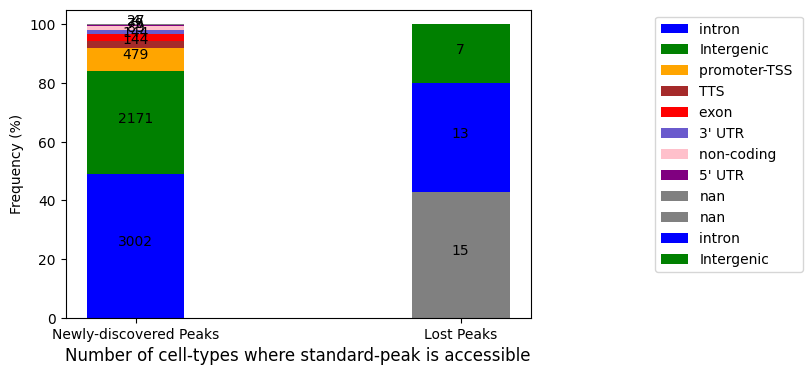

In [131]:
color_map = {'intron ': 'blue', 'promoter-TSS ': 'orange', 'Intergenic': 'green', 'exon ': 'red',
                "5' UTR ": 'purple', 'TTS ': 'brown', 'non-coding ': 'pink', "3' UTR ": 'slateblue', 'nan': 'grey'}
index_map = {'intron ': 0, 'promoter-TSS ': 1, 'Intergenic': 2, 'exon ': 3,
                "5' UTR ": 4, 'TTS ': 5, 'non-coding ': 6, "3' UTR ": 7, 'nan': 8}

width = 0.3  # the width of the bars
fig, ax = plt.subplots(   figsize=(6,4))

x = [0] 
bottom =np.array([.0])
for genome_type  in newly_discovered_peaks_freq.index.values:

    y_perc =np.array([newly_discovered_peaks_freq[genome_type]])  / newly_discovered_peaks_freq.sum() * 100
    rects = ax.bar( x, y_perc,  width, label=genome_type, color=color_map[genome_type], bottom=bottom)
    bottom += y_perc

    value_labels = [newly_discovered_peaks_freq[genome_type]]
    value_pos = 'center'
    ax.bar_label(rects, labels=value_labels , padding=3, fontsize=10, label_type=value_pos) 




x = [1]
bottom =np.array([.0])
for genome_type  in lost_peaks_freq.index.values:
    
    y_perc =np.array([lost_peaks_freq[genome_type]]) / lost_peaks_freq.sum() * 100
    rects = ax.bar( x, y_perc,  width, label=genome_type, color=color_map[genome_type], bottom=bottom)
    bottom += y_perc

    value_labels = [lost_peaks_freq[genome_type]]
    value_pos = 'center'
    ax.bar_label(rects, labels=value_labels , padding=3, fontsize=10, label_type=value_pos)
    
    
# Add some text for labels, title and custom x-axis tick labels, etc.
ax.set_ylabel('Frequency (%)')
ax.set_xlabel('Number of cell-types where standard-peak is accessible', fontsize=12) 
ax.set_xticks([0, 1], ['Newly-discovered Peaks', 'Lost Peaks'])
ax.legend(loc='upper right', ncols=1, bbox_to_anchor=(1.6, 1))



plt.show()

In [380]:
lost_peaks_freq ,  newly_discovered_peaks_freq, 



(simple_annotation
 nan           15
 intron        13
 Intergenic     7
 Name: count, dtype: int64,
 simple_annotation
 intron           3002
 Intergenic       2171
 promoter-TSS      479
 TTS               144
 exon              144
 3' UTR             89
 non-coding         79
 5' UTR             27
 nan                 4
 Name: count, dtype: int64)

In [382]:
lost_peaks_freq / lost_peaks_freq.sum(), newly_discovered_peaks_freq / newly_discovered_peaks_freq.sum()

(simple_annotation
 nan           0.428571
 intron        0.371429
 Intergenic    0.200000
 Name: count, dtype: float64,
 simple_annotation
 intron           0.489005
 Intergenic       0.353641
 promoter-TSS     0.078026
 TTS              0.023457
 exon             0.023457
 3' UTR           0.014497
 non-coding       0.012869
 5' UTR           0.004398
 nan              0.000652
 Name: count, dtype: float64)

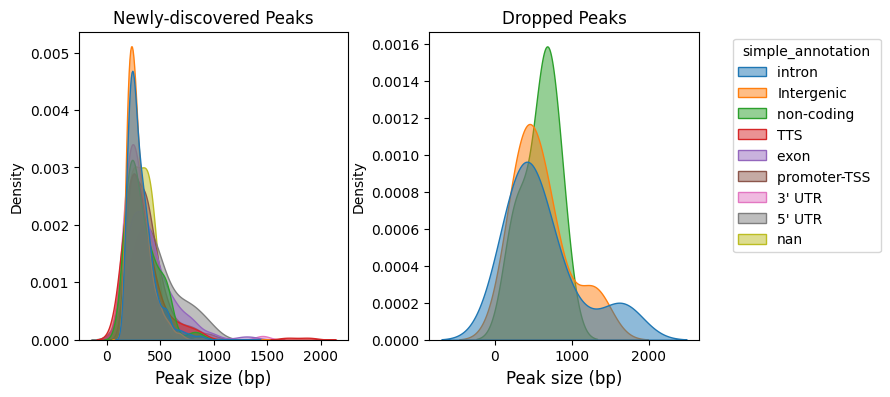

In [63]:
color_map = {'intron ': 'blue', 'promoter-TSS ': 'orange', 'Intergenic': 'green', 'exon ': 'red',
                "5' UTR ": 'purple', 'TTS ': 'brown', 'non-coding ': 'pink', "3' UTR ": 'slateblue', 'nan': 'grey'}
fig, ax = plt.subplots(1, 2, figsize=(8, 4))

sns.kdeplot(data=newly_discovered_peaks_annot, x='peak_size', hue='simple_annotation', fill=True, ax=ax[0], 
            common_norm=False, alpha=0.5, color=color_map)
sns.kdeplot(data=lost_peaks_annot, x='peak_size', hue='simple_annotation', fill=True, ax=ax[1], 
            common_norm=False, alpha=0.5, color=color_map)

ax[0].set_xlabel('Peak size (bp)', fontsize=12)
ax[0].set_title('Newly-discovered Peaks', fontsize=12)
ax[1].set_xlabel('Peak size (bp)', fontsize=12)
ax[1].set_title('Dropped Peaks', fontsize=12)


ax[1].legend_.remove()
sns.move_legend(ax[0], "upper right", bbox_to_anchor=(3, 1))

fig.subplots_adjust(wspace=0.3)

-------------- 	 Raw peaks , Entropy peaks , Newly-discovered peaks , Dropped peaks
Median peak size: ['534.5         ', '528.0         ', '283.0         ', '530.0         ']
Mean peak size: [699.3211852423191, 715.40638187808, 322.3182928815768, 604.1142857142858]


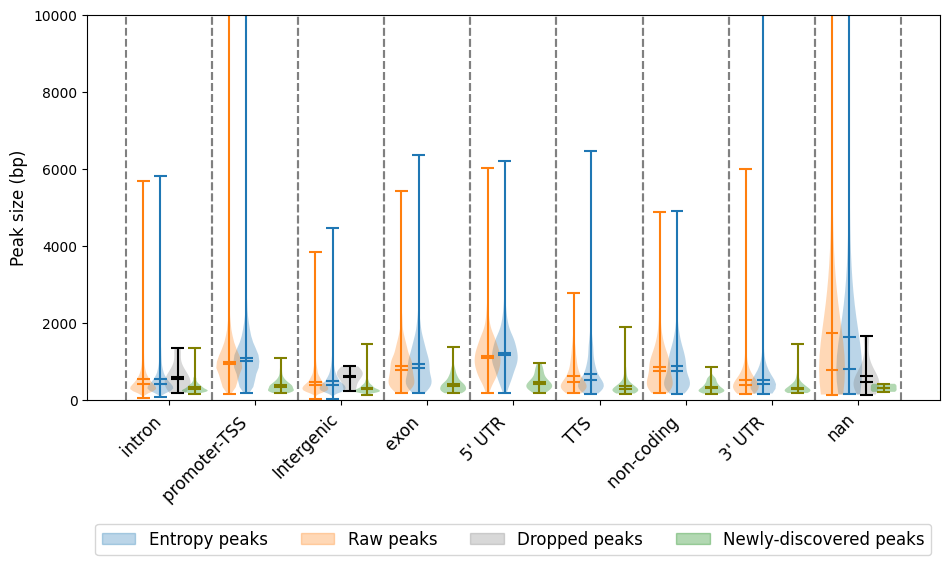

In [209]:
from matplotlib.pylab import size


position_map = {'intron ': 0, 'promoter-TSS ': 1, 'Intergenic': 2, 'exon ': 3,
                "5' UTR ": 4, 'TTS ': 5, 'non-coding ': 6, "3' UTR ": 7, 'nan': 8}

position_map_reversed = {v: k for k, v in position_map.items()}


def add_label(violin, label):
    color = violin["bodies"][0].get_facecolor().flatten()
    labels.append((mpatches.Patch(color=color), label))
    

x_positions = range(len(position_map)) 
width = 0.3  # the width of the bars
labels = []

fig, ax = plt.subplots( figsize=(11, 5))

standard_type = peaks_annot['simple_annotation'].unique()
entropy_type = entropy_peaks_annot['simple_annotation'].unique()
newly_discovered_type = newly_discovered_peaks_annot['simple_annotation'].unique()
lost_type = lost_peaks_annot['simple_annotation'].unique()

standard_peak_size = [ peaks_annot.loc[peaks_annot['simple_annotation'] == genome_type, 'peak_size'] for \
    genome_type in standard_type ]

entropy_peak_size = [ entropy_peaks_annot.loc[entropy_peaks_annot['simple_annotation'] == genome_type, 'peak_size'] for \
    genome_type in entropy_type ]
newly_discovered_peak_size = [ newly_discovered_peaks_annot.loc[newly_discovered_peaks_annot['simple_annotation'] == genome_type, 'peak_size'] for \
    genome_type in newly_discovered_type     ]  
lost_peak_size = [ lost_peaks_annot.loc[lost_peaks_annot['simple_annotation'] == genome_type, 'peak_size'] for \
    genome_type in lost_type ]


v2 =ax.violinplot( entropy_peak_size, 
              positions=[position_map[genome_type] - 0.1 for genome_type in entropy_type], widths=width, vert=True, 
              showmedians=True, showmeans=True,)
add_label(v2, 'Entropy peaks')

v1 = ax.violinplot( standard_peak_size, 
              positions=[position_map[genome_type] - 0.3 for genome_type in standard_type], widths=width, vert=True, 
              showmedians=True, showmeans=True,)
add_label(v1, 'Raw peaks')


v3 = ax.violinplot( lost_peak_size, 
              positions=[position_map[genome_type] + 0.1 for genome_type in lost_type], widths=width, vert=True, 
              showmedians=True, showmeans=True,)
# change color 
for body in v3['bodies']:
    body.set_facecolor( 'grey'   )
for partname in ('cbars','cmins','cmaxes','cmeans','cmedians'):
    v3[partname].set_edgecolor('black')
add_label(v3, 'Dropped peaks')


v4 =ax.violinplot( newly_discovered_peak_size, 
              positions=[position_map[genome_type] + 0.3 for genome_type in newly_discovered_type], widths=width, vert=True, 
              showmedians=True, showmeans=True,)
# change color
for body in v4['bodies']:
    body.set_facecolor('green')
for partname in ('cbars','cmins','cmaxes','cmeans','cmedians'):
    v4[partname].set_edgecolor('olive')

add_label(v4, 'Newly-discovered peaks')


## Add vertical line to separate each group
for x in x_positions:
    ax.vlines(x + 0.5 , ymin=0, ymax=20000, colors='grey', linestyles='--')
    ax.vlines(x - 0.5 , ymin=0, ymax=20000, colors='grey', linestyles='--')


ax.set_xticks(x_positions)
ax.set_xticklabels([position_map_reversed[i] for i in x_positions], rotation=45, ha='right', fontsize=12)
ax.set_ylim(0, 10000)
ax.set_ylabel('Peak size (bp)', fontsize=12)
plt.legend(*zip(*labels), loc='upper right', bbox_to_anchor=(1., -0.3), ncol=4, fontsize=12)

median_peak_size = [np.median(peaks_annot['peak_size']), np.median(entropy_peaks_annot['peak_size']),
                    np.median(newly_discovered_peaks_annot['peak_size']), np.median(lost_peaks_annot['peak_size'])]
mean_peak_size = [np.mean(peaks_annot['peak_size']), np.mean(entropy_peaks_annot['peak_size']),
                    np.mean(newly_discovered_peaks_annot['peak_size']), np.mean(lost_peaks_annot['peak_size'])]
print(f'-------------- \t Raw peaks , Entropy peaks , Newly-discovered peaks , Dropped peaks')
print(f'Median peak size: {[str(size) + "         " for size in median_peak_size]}') # show with 4 decimal places
print(f'Mean peak size: {mean_peak_size}')


In [69]:
newly_discovered_peaks_annot

,PeakID (cmd=annotatePeaks.pl /home/syyang/adipose_ln/atac/res/VIB_10xmultiome_2_WS3000F/peaks_comparison/newly_discovered_peaks.bed hg38 -annStats /home/syyang/adipose_ln/atac/res/VIB_10xmultiome_2_WS3000F/annotation/annStats_newly_discovered_peaks.txt),Chr,Start,End,Strand,Peak Score,Focus Ratio/Region Size,Annotation,Detailed Annotation,Distance to TSS,...,Entrez ID,Nearest Unigene,Nearest Refseq,Nearest Ensembl,Gene Name,Gene Alias,Gene Description,Gene Type,peak_size,simple_annotation
0,peak_3811,chr1,243748785,243748986,+,1000,NaN,"intron (NM_005465, intron 2 of 13)","intron (NM_005465, intron 2 of 13)",94397.0,...,10000.0,NaN,NM_005465,ENSG00000117020,AKT3,MPPH|MPPH2|PKB-GAMMA|PKBG|PRKBG|RAC-PK-gamma|R...,AKT serine/threonine kinase 3,protein-coding,201,intron
1,peak_12305,chr15,76151031,76151223,+,1000,NaN,"intron (NM_152335, intron 3 of 10)","intron (NM_152335, intron 3 of 10)",30359.0,...,101929439.0,NaN,NR_120360,ENSG00000259422,LOC101929439,-,uncharacterized LOC101929439,ncRNA,192,intron
2,peak_17933,chr19,9625903,9626104,+,1000,NaN,"intron (NR_122038, intron 1 of 3)",LTR55|LTR|ERVL?,4521.0,...,284385.0,NaN,NM_001242812,ENSG00000267106,ZNF561-AS1,C19orf82,ZNF561 antisense RNA 1 (head to head),ncRNA,201,intron
3,peak_18958,chr19,40614953,40615151,+,1000,NaN,"intron (NM_001042544, intron 22 of 32)","intron (NM_001042544, intron 22 of 32)",13683.0,...,8425.0,NaN,NM_003573,ENSG00000090006,LTBP4,ARCL1C|LTBP-4|LTBP4L|LTBP4S,latent transforming growth factor beta binding...,protein-coding,198,intron
4,peak_30635,chr6,32413545,32413747,+,1000,NaN,Intergenic,Intergenic,-6516.0,...,56244.0,NaN,NM_019602,ENSG00000204290,BTNL2,BTL-II|BTN7|HSBLMHC1|SS2,butyrophilin like 2,protein-coding,202,Intergenic
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6134,peak_1652,chr1,92482817,92484074,+,252,NaN,"exon (NM_001127215, exon 2 of 7)","exon (NM_001127215, exon 2 of 7)",509.0,...,2672.0,NaN,NM_005263,ENSG00000162676,GFI1,GFI-1|GFI1A|SCN2|ZNF163,growth factor independent 1 transcriptional re...,protein-coding,1257,exon
6135,peak_3612,chr1,227887092,227888084,+,252,NaN,Intergenic,Intergenic,54095.0,...,100847072.0,NaN,NR_049806,ENSG00000264483,MIR5008,-,microRNA 5008,ncRNA,992,Intergenic
6136,peak_11048,chr14,91254072,91254926,+,246,NaN,promoter-TSS (NM_001348437),promoter-TSS (NM_001348437),-619.0,...,8111.0,NaN,NM_003485,ENSG00000119714,GPR68,AI2A6|GPR12A|OGR1,G protein-coupled receptor 68,protein-coding,854,promoter-TSS
6137,peak_7531,chr11,128905212,128906163,+,234,NaN,promoter-TSS (NR_169216),promoter-TSS (NR_169216),22.0,...,219833.0,NaN,NM_145013,ENSG00000174370,KCNJ5-AS1,C11orf45,KCNJ5 antisense RNA 1,ncRNA,951,promoter-TSS


# Check cCRE annotations

In [92]:
cCRE_subdir=os.path.join(entropy_dir, 'cCRE_annotation')
cCRE_newly_discovered_peaks_file = os.path.join(cCRE_subdir, 'cCRE_annot_newly_discovered_peaks.bed')
cCRE_lost_peaks_file = os.path.join(cCRE_subdir, 'cCRE_annot_lost_peaks.bed')

cCRE_newly_discovered_peaks = pd.read_csv(cCRE_newly_discovered_peaks_file, sep='\t', header=None)
cCRE_lost_peaks = pd.read_csv(cCRE_lost_peaks_file, sep='\t', header=None)

columns = ['chrom', 'chromStart', 'chromEnd', 'name', 'peak_auc_score', 'strand', 'signalValue', 'pValue', 'qValue', 'peak', 
           'cCREs_chrom', 'cCREs_start', 'cCREs_end', 'cCREs_an1', 'cCREs_an2', 'encode_label', 'overlap_bp']

cCRE_lost_peaks.columns = columns
cCRE_newly_discovered_peaks.columns = columns

cCRE_lost_peaks.shape, cCRE_newly_discovered_peaks.shape,

((35, 17), (7834, 17))

In [93]:
cCRE_newly_discovered_peaks.head()

,chrom,chromStart,chromEnd,name,peak_auc_score,strand,signalValue,pValue,qValue,peak,cCREs_chrom,cCREs_start,cCREs_end,cCREs_an1,cCREs_an2,encode_label,overlap_bp
0,chr1,976091,976507,peak_37,718,.,298.735504,3.889666,-1,104,chr1,975985,976335,EH38D4327848,EH38E2776741,"dELS,CTCF-bound",244
1,chr1,976091,976507,peak_37,718,.,298.735504,3.889666,-1,104,chr1,976424,976654,EH38D4327849,EH38E2776742,"dELS,CTCF-bound",83
2,chr1,1079635,1080360,peak_48,378,.,273.890259,2.925810,-1,400,chr1,1079459,1079809,EH38D4328076,EH38E2776927,"dELS,CTCF-bound",174
3,chr1,1079635,1080360,peak_48,378,.,273.890259,2.925810,-1,400,chr1,1079868,1080027,EH38D2115702,EH38E1310453,"dELS,CTCF-bound",159
4,chr1,1079635,1080360,peak_48,378,.,273.890259,2.925810,-1,400,chr1,1080115,1080463,EH38D4328077,EH38E2776928,"dELS,CTCF-bound",245


In [94]:
cCRE_lost_peaks.head(10)

,chrom,chromStart,chromEnd,name,peak_auc_score,strand,signalValue,pValue,qValue,peak,cCREs_chrom,cCREs_start,cCREs_end,cCREs_an1,cCREs_an2,encode_label,overlap_bp
0,chr1,2663175,2663930,peak_134,342,.,257.992554,3.048749,-1,63,.,-1,-1,.,.,.,0
1,chr1,2664230,2665587,peak_135,371,.,503.672852,2.914509,-1,679,.,-1,-1,.,.,.,0
2,chr1,2671720,2672357,peak_136,436,.,277.447876,3.144313,-1,144,.,-1,-1,.,.,.,0
3,chr1,2748299,2748725,peak_138,501,.,213.434113,3.235945,-1,181,.,-1,-1,.,.,.,0
4,chr1,2756527,2757065,peak_139,509,.,273.738647,3.205816,-1,66,.,-1,-1,.,.,.,0
5,chr1,3501972,3502147,peak_143,1000,.,226.675674,3.767873,-1,85,chr1,3502064,3502405,EH38D4332663,EH38E2780238,dELS,83
6,chr1,16670242,16670866,peak_399,370,.,231.137512,2.982659,-1,296,.,-1,-1,.,.,.,0
7,chr1,16749721,16750351,peak_405,427,.,268.858154,3.235945,-1,423,.,-1,-1,.,.,.,0
8,chr1,144102142,144103010,peak_1824,240,.,208.247543,3.048749,-1,483,.,-1,-1,.,.,.,0
9,chr1,144843659,144844879,peak_1847,256,.,312.655212,2.879614,-1,809,.,-1,-1,.,.,.,0


In [95]:
# Total CREs lost peaks cover
cCRE_lost_peaks.loc[cCRE_lost_peaks['overlap_bp'] > 0].shape

(5, 17)

In [96]:
# total lost peaks that cover CREs 
len(cCRE_lost_peaks.loc[cCRE_lost_peaks['overlap_bp'] > 0 ]['name'].unique()) 

5

In [97]:
# Total CREs newly-discovered peaks cover
cCRE_newly_discovered_peaks.loc[cCRE_newly_discovered_peaks['overlap_bp'] > 0 ].shape  # total cCREs are covered 


(7697, 17)

In [98]:
# total newly-discovered peaks that cover CREs 
len(cCRE_newly_discovered_peaks.loc[cCRE_newly_discovered_peaks['overlap_bp'] > 0 ]['name'].unique()) 

6002

# Vis cCREs

/tmp/ipykernel_3495873/2718079941.py:14: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax[0].set_xticklabels(ax[0].x_ticklabels, rotation=45, ha='right', fontsize=10)
/tmp/ipykernel_3495873/2718079941.py:26: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax[1].set_xticklabels(ax[1].x_ticklabels, rotation=45, ha='right', fontsize=10)


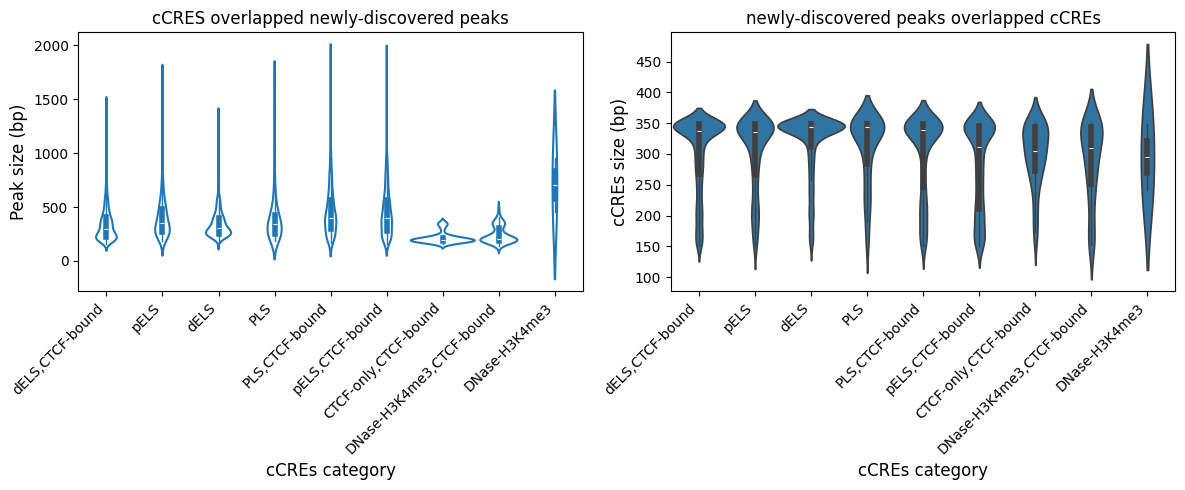

In [99]:
cCRE_newly_discovered_peaks['peak_size'] = cCRE_newly_discovered_peaks['chromEnd'] - cCRE_newly_discovered_peaks['chromStart']
cCRE_newly_discovered_peaks['cCREs_size'] = cCRE_newly_discovered_peaks['cCREs_end'] - cCRE_newly_discovered_peaks['cCREs_start']
cCRE_newly_discovered_peaks['overlap_cCREs'] = cCRE_newly_discovered_peaks['overlap_bp'] > 0 


fig, ax = plt.subplots( 1, 2, figsize=( 12, 5))


sns.violinplot(data=cCRE_newly_discovered_peaks.loc[cCRE_newly_discovered_peaks['overlap_bp'] > 0],
            y='peak_size', x='encode_label',  width=1.2,  inner_kws=dict(box_width=4, whis_width=1),
            fill=False, gap=.05, ax=ax[0])

ax[0].x_ticklabels = ax[0].get_xticklabels()
ax[0].set_xticklabels(ax[0].x_ticklabels, rotation=45, ha='right', fontsize=10)
ax[0].set_title('cCRES overlapped newly-discovered peaks', fontsize=12)
ax[0].set_xlabel('cCREs category', fontsize=12)
ax[0].set_ylabel('Peak size (bp)', fontsize=12)
# sns.move_legend(ax[0], "upper left", bbox_to_anchor=(1.03, 1))

sns.violinplot(data=cCRE_newly_discovered_peaks.loc[cCRE_newly_discovered_peaks['overlap_bp'] > 0], 
            y='cCREs_size', x='encode_label', width=1.2,  inner_kws=dict(box_width=4, whis_width=1),
            ax=ax[1])


ax[1].x_ticklabels = ax[1].get_xticklabels()
ax[1].set_xticklabels(ax[1].x_ticklabels, rotation=45, ha='right', fontsize=10)
ax[1].set_title('newly-discovered peaks overlapped cCREs', fontsize=12)
ax[1].set_xlabel('cCREs category', fontsize=12)
ax[1].set_ylabel('cCREs size (bp)', fontsize=12)


plt.tight_layout()


/tmp/ipykernel_3495873/3728394934.py:9: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax[0].set_xticklabels(ax[0].x_ticklabels, rotation=45, ha='right', fontsize=10)
/tmp/ipykernel_3495873/3728394934.py:22: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax[1].set_xticklabels(ax[1].x_ticklabels, rotation=45, ha='right', fontsize=10)


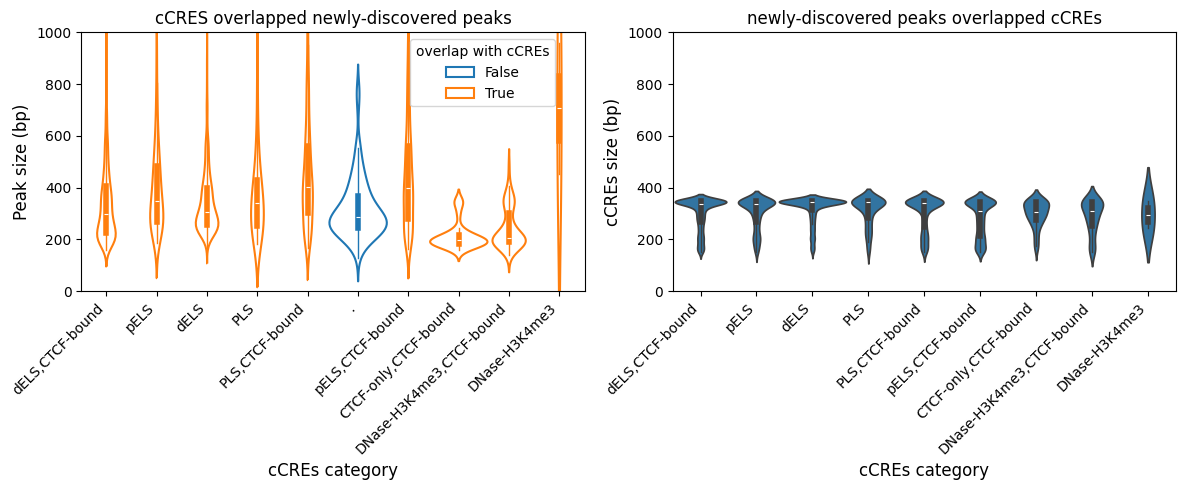

In [169]:

fig, ax = plt.subplots( 1, 2, figsize=( 12, 5))


sns.violinplot(data=cCRE_newly_discovered_peaks,
            y='peak_size', x='encode_label', hue='overlap_cCREs', width=1.2,  inner_kws=dict(box_width=4, whis_width=1),
            fill=False, gap=.05, ax=ax[0])

ax[0].x_ticklabels = ax[0].get_xticklabels()
ax[0].set_xticklabels(ax[0].x_ticklabels, rotation=45, ha='right', fontsize=10)
ax[0].set_title('cCRES overlapped newly-discovered peaks', fontsize=12)
ax[0].set_xlabel('cCREs category', fontsize=12)
ax[0].set_ylabel('Peak size (bp)', fontsize=12)
ax[0].legend(title='overlap with cCREs', loc='upper right', fontsize=10)
sns.move_legend(ax[0], "upper left", bbox_to_anchor=(0.64, 1))

sns.violinplot(data=cCRE_newly_discovered_peaks.loc[cCRE_newly_discovered_peaks['overlap_bp'] > 0], 
            y='cCREs_size', x='encode_label', width=1.2,  inner_kws=dict(box_width=4, whis_width=1),
            ax=ax[1])


ax[1].x_ticklabels = ax[1].get_xticklabels()
ax[1].set_xticklabels(ax[1].x_ticklabels, rotation=45, ha='right', fontsize=10)
ax[1].set_title('newly-discovered peaks overlapped cCREs', fontsize=12)
ax[1].set_xlabel('cCREs category', fontsize=12)
ax[1].set_ylabel('cCREs size (bp)', fontsize=12)


ax[0].set_ylim(0, 1000)
ax[1].set_ylim(0, 1000)

plt.tight_layout()

/tmp/ipykernel_3495873/3303746603.py:14: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax[0].set_xticklabels(ax[0].x_ticklabels, rotation=45, ha='right', fontsize=10)
/tmp/ipykernel_3495873/3303746603.py:26: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax[1].set_xticklabels(ax[1].x_ticklabels, rotation=45, ha='right', fontsize=10)


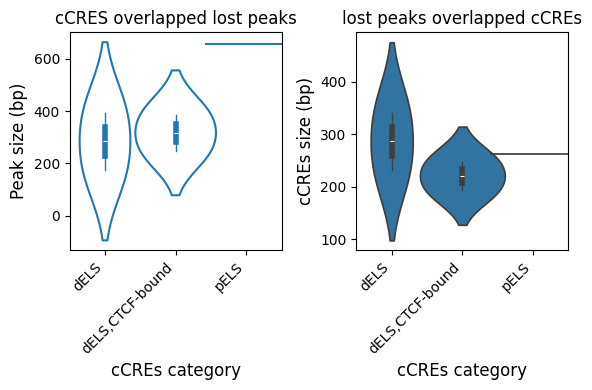

In [103]:
cCRE_lost_peaks['peak_size'] = cCRE_lost_peaks['chromEnd'] - cCRE_lost_peaks['chromStart']
cCRE_lost_peaks['cCREs_size'] = cCRE_lost_peaks['cCREs_end'] - cCRE_lost_peaks['cCREs_start']
cCRE_lost_peaks['overlap_cCREs'] = cCRE_lost_peaks['overlap_bp'] > 0 


fig, ax = plt.subplots( 1, 2, figsize=( 6, 4))


sns.violinplot(data=cCRE_lost_peaks.loc[cCRE_lost_peaks['overlap_bp'] > 0],
            y='peak_size', x='encode_label',  width=1.2,  inner_kws=dict(box_width=4, whis_width=1),
            fill=False, gap=.05, ax=ax[0])

ax[0].x_ticklabels = ax[0].get_xticklabels()
ax[0].set_xticklabels(ax[0].x_ticklabels, rotation=45, ha='right', fontsize=10)
ax[0].set_title('cCRES overlapped lost peaks', fontsize=12)
ax[0].set_xlabel('cCREs category', fontsize=12)
ax[0].set_ylabel('Peak size (bp)', fontsize=12)
# sns.move_legend(ax[0], "upper left", bbox_to_anchor=(1.03, 1))

sns.violinplot(data=cCRE_lost_peaks.loc[cCRE_lost_peaks['overlap_bp'] > 0], 
            y='cCREs_size', x='encode_label', width=1.2,  inner_kws=dict(box_width=4, whis_width=1),
            ax=ax[1])


ax[1].x_ticklabels = ax[1].get_xticklabels()
ax[1].set_xticklabels(ax[1].x_ticklabels, rotation=45, ha='right', fontsize=10)
ax[1].set_title('lost peaks overlapped cCREs', fontsize=12)
ax[1].set_xlabel('cCREs category', fontsize=12)
ax[1].set_ylabel('cCREs size (bp)', fontsize=12)


plt.tight_layout()

/tmp/ipykernel_3495873/4187390068.py:9: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax[0].set_xticklabels(ax[0].x_ticklabels, rotation=45, ha='right', fontsize=10)
/tmp/ipykernel_3495873/4187390068.py:22: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax[1].set_xticklabels(ax[1].x_ticklabels, rotation=45, ha='right', fontsize=10)


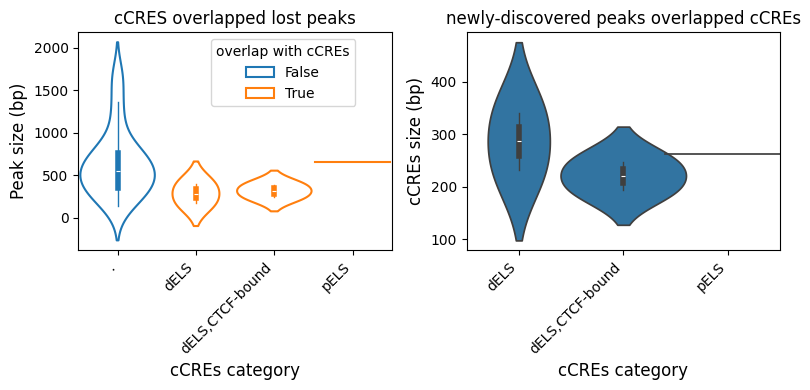

In [104]:

fig, ax = plt.subplots( 1, 2, figsize=( 8, 4))


sns.violinplot(data=cCRE_lost_peaks,
            y='peak_size', x='encode_label', hue='overlap_cCREs', width=1,  inner_kws=dict(box_width=4, whis_width=1),
            fill=False, gap=.05, ax=ax[0])

ax[0].x_ticklabels = ax[0].get_xticklabels()
ax[0].set_xticklabels(ax[0].x_ticklabels, rotation=45, ha='right', fontsize=10)
ax[0].set_title('cCRES overlapped lost peaks', fontsize=12)
ax[0].set_xlabel('cCREs category', fontsize=12)
ax[0].set_ylabel('Peak size (bp)', fontsize=12)
ax[0].legend(title='overlap with cCREs', loc='upper right', fontsize=10)
sns.move_legend(ax[0], "upper left", bbox_to_anchor=(0.4, 1))

sns.violinplot(data=cCRE_lost_peaks.loc[cCRE_lost_peaks['overlap_bp'] > 0], 
            y='cCREs_size', x='encode_label', width=1.2,  inner_kws=dict(box_width=4, whis_width=1),
            ax=ax[1])


ax[1].x_ticklabels = ax[1].get_xticklabels()
ax[1].set_xticklabels(ax[1].x_ticklabels, rotation=45, ha='right', fontsize=10)
ax[1].set_title('newly-discovered peaks overlapped cCREs', fontsize=12)
ax[1].set_xlabel('cCREs category', fontsize=12)
ax[1].set_ylabel('cCREs size (bp)', fontsize=12)


plt.tight_layout()

/tmp/ipykernel_3495873/2300342072.py:14: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  g1 = sns.kdeplot(data=cCRE_lost_peaks, x='peak_size', hue='covered_cCREs_category', fill=True, ax=ax[1],


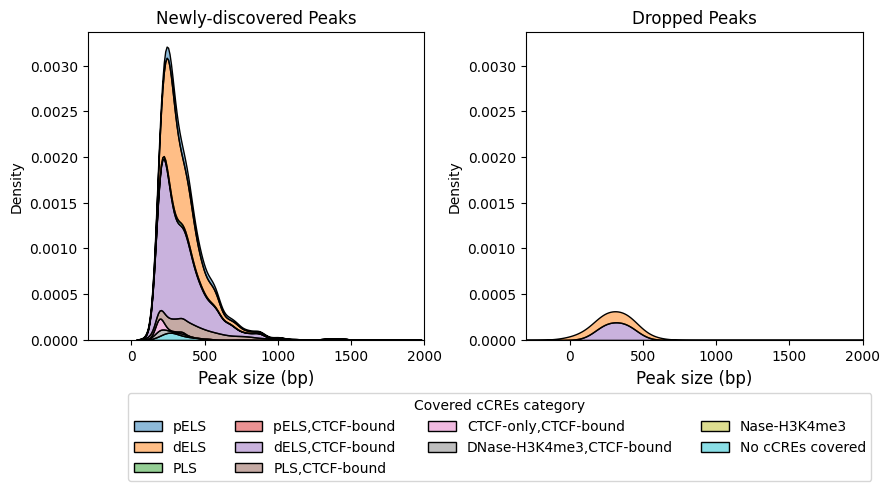

In [211]:
cCRE_newly_discovered_peaks['covered_cCREs_category'] = cCRE_newly_discovered_peaks['encode_label'] 
cCRE_newly_discovered_peaks.loc[cCRE_newly_discovered_peaks['encode_label'] == '.', 'covered_cCREs_category'] = 'No cCREs covered'

cCRE_lost_peaks['covered_cCREs_category'] = cCRE_lost_peaks['encode_label']
cCRE_lost_peaks.loc[cCRE_lost_peaks['encode_label'] == '.', 'covered_cCREs_category'] = 'No cCREscovered'

hue_color = ['pELS', 'dELS', 'PLS', 
             'pELS,CTCF-bound ',  'dELS,CTCF-bound', "PLS,CTCF-bound", 
             'CTCF-only,CTCF-bound', "DNase-H3K4me3,CTCF-bound", 'Nase-H3K4me3', 'No cCREs covered']
fig, ax = plt.subplots(1, 2, figsize=(10, 4))

g0 = sns.kdeplot(data=cCRE_newly_discovered_peaks, x='peak_size', hue='covered_cCREs_category', fill=True, ax=ax[0], 
            common_norm=True, alpha=0.5, hue_order=hue_color, multiple='stack')
g1 = sns.kdeplot(data=cCRE_lost_peaks, x='peak_size', hue='covered_cCREs_category', fill=True, ax=ax[1], 
            common_norm=True, alpha=0.5, hue_order=hue_color, multiple='stack')

ax[0].set_xlabel('Peak size (bp)', fontsize=12)
ax[0].set_title('Newly-discovered Peaks', fontsize=12)
ax[1].set_xlabel('Peak size (bp)', fontsize=12)
ax[1].set_title('Dropped Peaks', fontsize=12)

ax[0].set_xlim(-300, 2000)
ax[1].set_xlim(-300, 2000)
ax[0].set_xticks(np.arange(0, 2001, 500))
ax[1].set_xticks(np.arange(0, 2001, 500))
ax[0].set_ylim(0, ax[0].get_ylim()[1])
ax[1].set_ylim(0, ax[0].get_ylim()[1])
ax[0].set_yticks(np.arange(0, ax[0].get_ylim()[1], 0.0005))
ax[1].set_yticks(np.arange(0, ax[0].get_ylim()[1] , 0.0005))

# leg0 = ax[0].legend(title='Cover cCREs', labels=['False', 'True'], loc='upper right', frameon=True, shadow=False, borderpad=1)
# leg1 = ax[1].legend(title='Cover cCREs', labels=['False', 'True'], loc='upper right', frameon=True, shadow=False, borderpad=1)

ax[1].legend_.remove()
sns.move_legend(ax[0], "upper left", bbox_to_anchor=(0.1, -.15), title='Covered cCREs category', fontsize=10, ncol=4)


fig.subplots_adjust(wspace=0.3)

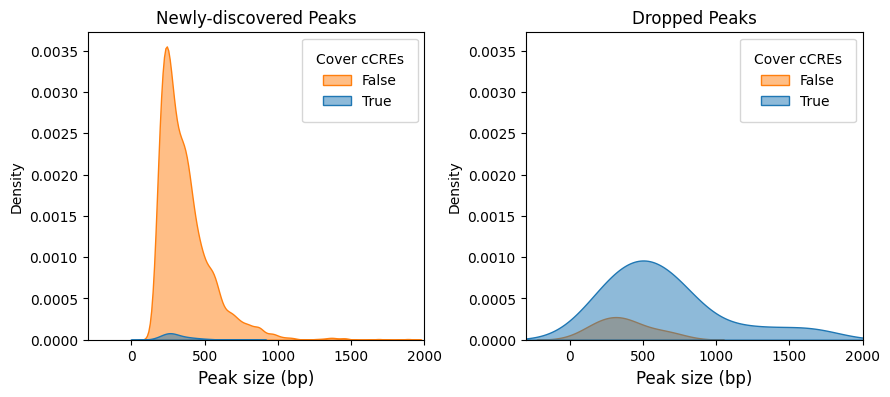

In [197]:
fig, ax = plt.subplots(1, 2, figsize=(10, 4))

g0 = sns.kdeplot(data=cCRE_newly_discovered_peaks, x='peak_size', hue='overlap_cCREs', fill=True, ax=ax[0], 
            common_norm=True, alpha=0.5, color=['green', 'grey'])
g1 = sns.kdeplot(data=cCRE_lost_peaks, x='peak_size', hue='overlap_cCREs', fill=True, ax=ax[1], 
            common_norm=True, alpha=0.5, color=['green', 'grey'])

ax[0].set_xlabel('Peak size (bp)', fontsize=12)
ax[0].set_title('Newly-discovered Peaks', fontsize=12)
ax[1].set_xlabel('Peak size (bp)', fontsize=12)
ax[1].set_title('Dropped Peaks', fontsize=12)

ax[0].set_xlim(-300, 2000)
ax[1].set_xlim(-300, 2000)
ax[0].set_xticks(np.arange(0, 2001, 500))
ax[1].set_xticks(np.arange(0, 2001, 500))
ax[0].set_ylim(0, ax[0].get_ylim()[1])
ax[1].set_ylim(0, ax[0].get_ylim()[1])
ax[0].set_yticks(np.arange(0, ax[0].get_ylim()[1], 0.0005))
ax[1].set_yticks(np.arange(0, ax[0].get_ylim()[1] , 0.0005))

leg0 = ax[0].legend(title='Cover cCREs', labels=['False', 'True'], loc='upper right', frameon=True, shadow=False, borderpad=1)
leg1 = ax[1].legend(title='Cover cCREs', labels=['False', 'True'], loc='upper right', frameon=True, shadow=False, borderpad=1)

# ax[1].legend_.remove()
# sns.move_legend(ax[0], "upper right", bbox_to_anchor=(2.8, 1))


fig.subplots_adjust(wspace=0.3)